# Four-way noise comparison: REAL / CONA / DEEP / GP

The definitive comparison of the three synthetic rotor-noise families against real
recordings, **over the same ground-truth RPS trajectories** (campaign criteria 3.2+3.3):

| row | source | RPS conditioning |
|---|---|---|
| **REAL** | near-constant-RPS cruise window from the free-flight recording | (ground truth) |
| **CONA** | CONA-auralized constant-rps case (dload `drone-egonoise@2e6644161ce1`) nearest the window's mean RPS | constant (mismatch stated) |
| **DEEP** | corrected-geometry generator `gen_v1_corrected` (E6-winner arch, per-drone learnable jitter σ) | true telemetry trajectory |
| **GP** | `EgonoiseGPModel` (JASA construct on the CONA sweep) FM-trajectory synthesis + broadband | rotor-mean telemetry trajectory |

All rows at 16 kHz, at the **real reference microphone's body-frame position**
(CONA: nearest of its 64 shell mics; GP: queried exactly at the real mic xyz).
Protocol/metrics follow `noise_gen_real_vs_generated.ipynb` + the E6 comb-mask
convention (`docs/experiments/noise-gen-linewidth.md`): comb-masked mean
|Δlog-mag| per k-band, msSTFT, harmonic-masked broadband floor/tilt, harmonic
linewidth (FWHM), inter-mic magnitude-squared coherence. Heavy lifting lives in
`notebooks/four_way_lib.py`.

**Level convention** — absolute calibration differs per family (digital units vs Pa),
so each synthetic row is RMS-aligned to REAL by a single scalar; the native offset is
reported as its own `level_off_dB` metric column.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import Audio, display

import four_way_lib as fw

SR = fw.SR
CONA_VERSION = "2e6644161ce1"          # 40 constant-rps cases, 2 drones x rps 40..85 x 2 seeds
CONA_CACHE = PROJECT_ROOT / ".cache" / "cona_cases"
DEEP_CKPT = PROJECT_ROOT / ".cache/r2_checkpoints/ml-data__artifacts__gen_v1_corrected__checkpoints__best.ckpt"
GP_CKPT = {
    "dregon": PROJECT_ROOT / "omnirun-outputs/python-fbd20f/results/gp_egonoise/dregon/best.pt",
    # matrice100 GP is still training — drop its best.pt here when it lands:
    "matrice100": PROJECT_ROOT / "omnirun-outputs/results/gp_egonoise/matrice100/best.pt",
}
METRIC_DUR_S = 2.0                     # CONA cases are 2 s long -> uniform window for all rows
torch.manual_seed(0)
print("deep ckpt:", DEEP_CKPT.exists(), "| gp dregon:", GP_CKPT["dregon"].exists(),
      "| gp matrice100:", GP_CKPT["matrice100"].exists())


deep ckpt: True | gp dregon: True | gp matrice100: False


## DREGON

REAL = `free-flight_nosource_room1` (8-mic cube array, corrected geometry via
`dregon.get_geometry`). The cruise window is auto-selected as the flattest 2 s
(minimal per-rotor RPS std with rotor-mean inside the CONA sweep support 40–85 rev/s).


In [2]:
tf_dregon = fw.load_dregon_recording(PROJECT_ROOT, "free-flight_nosource_room1")
start_s, rps_mean, rps_maxstd = fw.find_cruise_window(tf_dregon, dur_s=METRIC_DUR_S)
win = fw.slice_window(tf_dregon, start_s, METRIC_DUR_S)
print(f"cruise window: t=[{start_s:.1f}, {start_s + METRIC_DUR_S:.1f}] s   "
      f"rotor-mean RPS={rps_mean:.2f}  max per-rotor std={rps_maxstd:.2f} rev/s")
print("per-rotor mean RPS:", win["rps"].mean(1).round(2))
print("per-rotor std  RPS:", win["rps"].std(1).round(2))


cruise window: t=[30.5, 32.5] s   rotor-mean RPS=80.67  max per-rotor std=0.43 rev/s
per-rotor mean RPS: [86.46 75.15 85.33 75.74]
per-rotor std  RPS: [0.41 0.37 0.42 0.42]


In [3]:
# --- microphone selection ---------------------------------------------------------
# ref mic = mic 0 (repo convention); coherence partner = the real mic farthest from it.
MIC_REF = 0
d_ref = np.linalg.norm(win["mic_pos"] - win["mic_pos"][MIC_REF], axis=1)
MIC_B = int(np.argmax(d_ref))
print(f"real ref mic {MIC_REF} @ {win['mic_pos'][MIC_REF].round(3)}  "
      f"| partner mic {MIC_B} @ {win['mic_pos'][MIC_B].round(3)}  "
      f"(separation {d_ref[MIC_B]:.3f} m)")

# CONA: nearest constant-rps case + nearest shell mics to the two real mics
inv = fw.cona_inventory(version=CONA_VERSION)
cona_key = fw.nearest_cona_key(inv, "dregon", rps_mean, seed=0)
cona_rps = inv[cona_key]["rps"]
print(f"CONA case: {cona_key}  (rps={cona_rps:.0f}, "
      f"mismatch {cona_rps - rps_mean:+.2f} rev/s vs window mean {rps_mean:.2f})")
cona = fw.fetch_cona_case(cona_key, CONA_CACHE, version=CONA_VERSION)
cm0, cd0 = fw.nearest_mic(cona["mics_body"], win["mic_pos"][MIC_REF])
cm1, cd1 = fw.nearest_mic(cona["mics_body"], win["mic_pos"][MIC_B])
print(f"CONA shell mic for ref: #{cm0} @ {cona['mics_body'][cm0].round(3)} ({cd0:.3f} m away)")
print(f"CONA shell mic for partner: #{cm1} @ {cona['mics_body'][cm1].round(3)} ({cd1:.3f} m away)")
print("NOTE: CONA mics live on a 0.45-0.7 m shell; the real cube mics sit at ~0.1 m —"
      " nearest-mic matching is directional, not positional.")


real ref mic 0 @ [-0.042 -0.062 -0.041]  | partner mic 3 @ [0.062 0.042 0.041]  (separation 0.168 m)


CONA case: dregon_R080p0_A10p0_D02p0_M064_s000  (rps=80, mismatch -0.67 rev/s vs window mean 80.67)


CONA shell mic for ref: #23 @ [-0.211 -0.337 -0.211] (0.365 m away)
CONA shell mic for partner: #6 @ [0.205 0.298 0.267] (0.371 m away)
NOTE: CONA mics live on a 0.45-0.7 m shell; the real cube mics sit at ~0.1 m — nearest-mic matching is directional, not positional.


In [4]:
# --- build the four rows (2 mics each: [ref, partner]) ----------------------------
mics_sel = [MIC_REF, MIC_B]
real = win["target"][mics_sel].astype(np.float32)                      # (2, T)

deep_model = fw.load_deep_generator(DEEP_CKPT)
deep = fw.render_deep(deep_model, win["rps"], win["rel"][mics_sel], "dregon", rps_jitter=True)

cona_full = fw.resample_to_sr(cona["audio"][[cm0, cm1]])[:, : real.shape[1]]

gp = fw.load_gp(GP_CKPT["dregon"])
gp_row = fw.render_gp(gp, win["mic_pos"][mics_sel], win["rps"].mean(0), broadband=True)

ROWS = {"REAL": real, "CONA": cona_full, "DEEP": deep, "GP": gp_row}
level_off = {}
for name in ("CONA", "DEEP", "GP"):
    aligned = np.stack([fw.align_rms(ROWS[name][i], real[i])[0] for i in range(2)])
    level_off[name] = fw.rms_db(ROWS[name][0]) - fw.rms_db(real[0])
    ROWS[name] = aligned
level_off["REAL"] = 0.0
for n_, x in ROWS.items():
    print(f"{n_:5s} shape={x.shape}  native level offset vs REAL: {level_off[n_]:+.1f} dB")


REAL  shape=(2, 32000)  native level offset vs REAL: +0.0 dB
CONA  shape=(2, 32000)  native level offset vs REAL: +43.9 dB
DEEP  shape=(2, 32000)  native level offset vs REAL: -3.6 dB
GP    shape=(2, 32000)  native level offset vs REAL: +38.8 dB


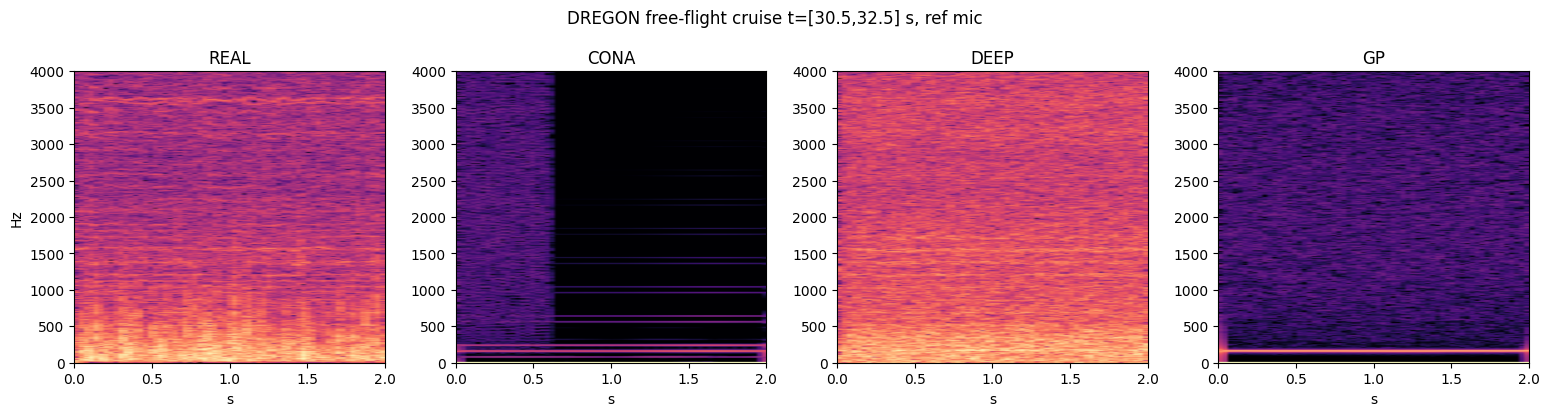

REAL:


CONA:


DEEP:


GP:


In [5]:
%matplotlib inline
# (train_egonoise_gp.py forces the Agg backend at import — re-assert inline here)
# --- spectrogram grid (repo convention: dB log-STFT, n_fft=2048, hop=512, to 4 kHz) --
def spectrogram_grid(rows, dur_s, title, n_fft=2048, hop=512, fmax=4000):
    Ss = {n_: fw.logspec(x[0], n_fft, hop) for n_, x in rows.items()}
    nb_ = int(fmax / (SR / n_fft))
    vmax = Ss["REAL"][:nb_].max(); vmin = vmax - 80
    fig, ax = plt.subplots(1, len(rows), figsize=(3.9 * len(rows), 4.2), squeeze=False)
    for j, (n_, S) in enumerate(Ss.items()):
        ax[0, j].imshow(S[:nb_], origin="lower", aspect="auto", vmin=vmin, vmax=vmax,
                        cmap="magma", extent=[0, dur_s, 0, fmax])
        ax[0, j].set_title(n_); ax[0, j].set_xlabel("s")
    ax[0, 0].set_ylabel("Hz")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

spectrogram_grid(ROWS, METRIC_DUR_S,
                 f"DREGON free-flight cruise t=[{start_s:.1f},{start_s+METRIC_DUR_S:.1f}] s, ref mic")
for n_, x in ROWS.items():
    print(f"{n_}:"); display(Audio(x[0], rate=SR, normalize=True))


In [6]:
# --- metrics table (per row vs REAL, ref mic; coherence = ref vs partner mic) -----
# Linewidth is measured against each row's OWN comb (self-referenced): REAL/DEEP
# follow rotor 0's fundamental; CONA its constant rps; GP renders only BPF
# multiples (= even rotor harmonics), so its ks are BPF-harmonics 5/8/10/13
# ~= rotor-k 10/16/20/26 slotted into the same columns.
KLABELS = ("k~10", "k~15", "k~20", "k~25")


def metrics_table(rows, rps, lw_refs):
    recs = []
    for n_, x in rows.items():
        rec = {"row": n_}
        if n_ != "REAL":
            rec.update({f"comb[{b}]": v
                        for b, v in fw.comb_error(rows["REAL"][0], x[0], rps).items()})
            rec["msSTFT"] = fw.msstft_distance(rows["REAL"][0], x[0])
        fl, tl = fw.floor_and_tilt(x[0])
        rec["floor@1k_dB"] = fl
        rec["tilt_dB/oct"] = tl
        f0_row, ks = lw_refs[n_]
        lw = fw.linewidth_fwhm(x[0], f0_row, ks=ks)
        for lab, k in zip(KLABELS, ks):
            rec[f"FWHM_{lab}_Hz"] = lw[k]
        rec.update({f"MSC[{b}]": v for b, v in fw.band_coherence(x[0], x[1]).items()})
        recs.append(rec)
    return pd.DataFrame(recs).set_index("row")


f0_r0 = float(win["rps"][0].mean())  # rotor 0's fundamental (self-referenced linewidth)
lw_refs = {
    "REAL": (f0_r0, (10, 15, 20, 25)),
    "DEEP": (f0_r0, (10, 15, 20, 25)),
    "CONA": (float(cona_rps), (10, 15, 20, 25)),
    "GP": (2.0 * rps_mean, (5, 8, 10, 13)),  # BPF comb -> rotor-k 10/16/20/26
}
df_dregon = metrics_table(ROWS, win["rps"], lw_refs)
df_dregon.insert(0, "level_off_dB", pd.Series(level_off))
with pd.option_context("display.width", 220, "display.max_columns", 30):
    display(df_dregon.round(2))
print("Welch resolution floor for FWHM: ~2.9 Hz (clean tones pin to it).")
print("comb[...] samples REAL's telemetry tracks in BOTH spectrograms — for CONA "
      "(constant rps) and GP (even harmonics only) part of the error is the row "
      "missing those tracks entirely, which is exactly the documented family gap.")


,level_off_dB,floor@1k_dB,tilt_dB/oct,FWHM_k~10_Hz,FWHM_k~15_Hz,FWHM_k~20_Hz,FWHM_k~25_Hz,MSC[0-500Hz],MSC[500-1500Hz],MSC[1500-4000Hz],comb[k<10],comb[10-25],comb[25-40],msSTFT
row,,,,,,,,,,,,,,
REAL,0.00,-73.34,-7.89,11.23,10.25,8.30,2.93,0.05,0.19,0.18,NaN,NaN,NaN,NaN
CONA,43.95,-109.68,1.00,3.42,6.35,5.86,3.91,0.29,0.14,0.11,50.11,52.93,51.96,30.94
DEEP,-3.58,-68.55,-4.72,4.88,3.42,3.91,5.37,0.69,0.20,0.38,7.01,8.15,9.47,6.85
GP,38.80,-103.39,1.92,5.86,3.91,6.35,7.32,0.37,0.04,0.03,39.07,26.82,19.12,15.62


Welch resolution floor for FWHM: ~2.9 Hz (clean tones pin to it).
comb[...] samples REAL's telemetry tracks in BOTH spectrograms — for CONA (constant rps) and GP (even harmonics only) part of the error is the row missing those tracks entirely, which is exactly the documented family gap.


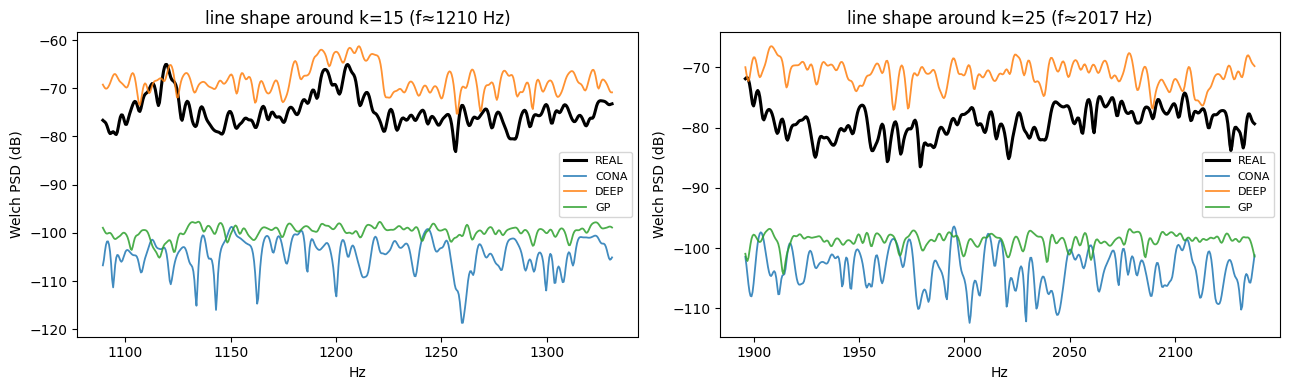

In [7]:
%matplotlib inline
# --- line-shape overlay: time-averaged spectrum around two mid-k harmonics --------
from scipy.signal import welch

def lineshape_overlay(rows, f0_mean, ks=(15, 25), half_bw=None, nperseg=8192):
    half_bw = half_bw or 1.5 * f0_mean  # wide enough to include every family's comb lines
    fig, axs = plt.subplots(1, len(ks), figsize=(6.5 * len(ks), 4), squeeze=False)
    for j, k in enumerate(ks):
        fc = k * f0_mean
        for n_, x in rows.items():
            f, P = welch(x[0].astype(np.float64), fs=SR, window="hann",
                         nperseg=nperseg, noverlap=nperseg // 2, nfft=nperseg * 4)
            sel = (f >= fc - half_bw) & (f <= fc + half_bw)
            kw = dict(lw=2.2, color="k") if n_ == "REAL" else dict(lw=1.3, alpha=0.85)
            axs[0, j].plot(f[sel], 10 * np.log10(P[sel] + 1e-18), label=n_, **kw)
        axs[0, j].set_title(f"line shape around k={k} (f≈{fc:.0f} Hz)")
        axs[0, j].set_xlabel("Hz"); axs[0, j].set_ylabel("Welch PSD (dB)")
        axs[0, j].legend(fontsize=8)
    plt.tight_layout(); plt.show()

lineshape_overlay(ROWS, rps_mean)


In [8]:
# --- CONA broadband-channel artifact check ---------------------------------------
# The spectrogram shows CONA's mid-band texture dying at ~0.65 s. The npz shows why:
# the TOTAL audio is stationary (tonal-dominated), but the separate broadband
# channel is only rendered for the first ~0.65 s of the 2 s case — an upstream
# auralization artifact. Since broadband sits ~36 dB below tonal it barely moves
# RMS, but the floor metric averages over the dead region, so also report the
# floor on the alive slice.
bb = cona["broadband"][cm0].astype(np.float64)
seg = len(bb) // 10
seg_rms = np.array([np.sqrt(np.mean(bb[i*seg:(i+1)*seg]**2)) for i in range(10)])
print("CONA broadband per-0.2s-segment RMS:", seg_rms.round(4))
alive = fw.floor_and_tilt(ROWS["CONA"][0][: int(0.6 * SR)])
print(f"CONA floor/tilt on alive 0.6 s slice: {alive[0]:.1f} dB @1kHz, {alive[1]:.2f} dB/oct "
      f"(vs {df_dregon.loc['CONA', 'floor@1k_dB']:.1f} / {df_dregon.loc['CONA', 'tilt_dB/oct']:.2f} on the full 2 s)")


CONA broadband per-0.2s-segment RMS: [0.1445 0.1424 0.1378 0.     0.     0.     0.     0.     0.     0.    ]
CONA floor/tilt on alive 0.6 s slice: -109.0 dB @1kHz, 1.43 dB/oct (vs -109.7 / 1.00 on the full 2 s)


## DREGON findings (numbers from the tables/figures above)

**Ranking on this cruise window (t=[30.5, 32.5] s, rotor-mean 80.7 rev/s, per-rotor 75.2–86.5): DEEP ≫ GP > CONA.**

- **DEEP** (`gen_v1_corrected`, jitter on): comb-masked |Δlog-mag| **7.0 / 8.2 / 9.5 dB** (k<10 / 10–25 / 25–40),
  msSTFT **6.9** — in line with the E6 jitter_latreg numbers (7.0/6.4/6.4 on a 4 s window) and far ahead of the
  other families in every band. Native level within **−3.6 dB** of real. Remaining gaps: broadband floor slightly
  hot and too flat (−68.6 dB @1 kHz, tilt −4.7 dB/oct vs real −73.3 / −7.9 → it overshoots real by ~5–8 dB above
  ~1.2 kHz, visible in the line-shape overlay), harmonic lines still too narrow (FWHM 3.4–5.4 Hz vs real 8–11 Hz
  at k≈10–20; learned σ≈0.59 rev/s is in the narrowband-FM regime), and **too coherent across mics**
  (MSC 0.69 vs real 0.05 at 0–500 Hz) — exactly the lever the v3 wind/incoherence channel targets.
- **GP**: msSTFT **15.6**, comb **39.1 / 26.8 / 19.1 dB**. It renders only BPF multiples (= even rotor harmonics,
  all four rotors collapsed to the rotor-mean), so odd-k tracks and the 75/86 rev/s rotor split are structurally
  missing; mid-band energy sits ~25–30 dB under real, broadband floor −103 dB with a positive tilt (+1.9 dB/oct).
  Its clean FM comb is resolution-limited in width. Also note the spatial extrapolation: queried at the real mic
  radius (~0.09 m) while trained on the 0.45–0.7 m shell.
- **CONA**: msSTFT **30.9**, comb **50–53 dB** across all bands — the constant-rps case (mismatch −0.67 rev/s on
  the mean, but really: one rps for all four rotors vs a real 11 rev/s rotor spread) puts its clean,
  resolution-limited tones off every real telemetry track, and its mid/high band is ~30 dB under real. Its
  broadband channel is both weak (~36 dB below tonal) and truncated at ~0.65 s (artifact above).

**Honesty caveats.** (1) This DREGON window lies in the deep generator's *training* region (the swapped split
holds out only takeoff), and the deep gen has an E4 history of exploitable artifacts — its lead is real but reads
as in-train performance. (2) The comb metric samples the *real* telemetry tracks in both spectrograms, which by
construction punishes CONA's constant comb and GP's even-harmonic comb for missing tracks — that is the
documented family gap, not a bug, but it is why their comb numbers are so large. (3) Single 2-s window (CONA case
length); levels aligned by one scalar per row. (4) CONA's coherence pair uses shell mics ~0.37 m from the real
mics (directional, not positional match).


## Matrice 100 (Michael's FLY124) — parked until the matrice100 GP lands

The pipeline below is the same 4-way build for the DJI Matrice 100
(REAL = FLY124 stable cruise slice, per-frame mean RPS > 45; CONA drone key
`matrice100`; DEEP codebook entry `michaels`). It is **guarded off** because the
matrice100 GP checkpoint is still training (kaggle job). To run:

1. `omnirun pull` the finished GP job and set `GP_CKPT["matrice100"]` above to its `best.pt`;
2. flip `RUN_MATRICE100 = True`;
3. re-run from here. Check the CONA `matrice100` `mics_body` frame against
   `load_michaels_timeframes` mic geometry (horizontal ring, z≈0.33 m) before
   trusting the nearest-mic pick.


In [9]:
%matplotlib inline
RUN_MATRICE100 = False  # flip when the matrice100 GP checkpoint is available

if RUN_MATRICE100 and GP_CKPT["matrice100"].exists():
    from data_processing.michaels import load_michaels_timeframes

    tf_m100 = load_michaels_timeframes(data_root=PROJECT_ROOT / "data", sr=SR)[0]  # FLY124
    m_start, m_rps_mean, m_rps_std = fw.find_cruise_window(tf_m100, dur_s=METRIC_DUR_S,
                                                           rps_range=(45.0, 85.0))
    m_win = fw.slice_window(tf_m100, m_start, METRIC_DUR_S)
    m_real = m_win["target"][[0, 4]].astype(np.float32)
    m_key = fw.nearest_cona_key(inv, "matrice100", m_rps_mean, seed=0)
    m_cona_raw = fw.fetch_cona_case(m_key, CONA_CACHE, version=CONA_VERSION)
    mm0, _ = fw.nearest_mic(m_cona_raw["mics_body"], m_win["mic_pos"][0])
    mm1, _ = fw.nearest_mic(m_cona_raw["mics_body"], m_win["mic_pos"][4])
    m_rows = {
        "REAL": m_real,
        "CONA": fw.resample_to_sr(m_cona_raw["audio"][[mm0, mm1]])[:, : m_real.shape[1]],
        "DEEP": fw.render_deep(deep_model, m_win["rps"], m_win["rel"][[0, 4]], "michaels"),
        "GP": fw.render_gp(fw.load_gp(GP_CKPT["matrice100"]), m_win["mic_pos"][[0, 4]],
                            m_win["rps"].mean(0)),
    }
    m_level = {"REAL": 0.0}
    for nm in ("CONA", "DEEP", "GP"):
        m_level[nm] = fw.rms_db(m_rows[nm][0]) - fw.rms_db(m_real[0])
        m_rows[nm] = np.stack([fw.align_rms(m_rows[nm][i], m_real[i])[0] for i in range(2)])
    spectrogram_grid(m_rows, METRIC_DUR_S, f"Matrice 100 FLY124 cruise t={m_start:.1f}s")
    for nm, x in m_rows.items():
        print(f"{nm}:"); display(Audio(x[0], rate=SR, normalize=True))
    m_f0r0 = float(m_win["rps"][0].mean())
    m_lw_refs = {
        "REAL": (m_f0r0, (10, 15, 20, 25)),
        "DEEP": (m_f0r0, (10, 15, 20, 25)),
        "CONA": (float(inv[m_key]["rps"]), (10, 15, 20, 25)),
        "GP": (2.0 * m_rps_mean, (5, 8, 10, 13)),
    }
    df_m100 = metrics_table(m_rows, m_win["rps"], m_lw_refs)
    df_m100.insert(0, "level_off_dB", pd.Series(m_level))
    display(df_m100.round(2))
else:
    print("matrice100 section skipped (RUN_MATRICE100 =", RUN_MATRICE100,
          "| GP ckpt exists =", GP_CKPT["matrice100"].exists(), ")")


matrice100 section skipped (RUN_MATRICE100 = False | GP ckpt exists = False )


## Overall verdict (3.3) — dregon half

Per-band and overall, on real DREGON free-flight cruise at the same ground-truth RPS:

| band | best | second | third |
|---|---|---|---|
| k<10 (low harmonics) | **DEEP** (7.0 dB) | GP (39.1) | CONA (50.1) |
| k 10–25 (mid) | **DEEP** (8.2 dB) | GP (26.8) | CONA (52.9) |
| k 25–40 (high) | **DEEP** (9.5 dB) | GP (19.1) | CONA (52.0) |
| broadband floor/tilt | **DEEP** (−68.6 dB, −4.7 dB/oct vs real −73.3, −7.9) | GP | CONA |
| linewidth realism | **DEEP** (still ~2× too narrow) | GP/CONA (resolution-limited clean tones) | — |
| inter-mic coherence | none — all synthetic rows are far too coherent (real MSC 0.05–0.19; DEEP 0.20–0.69, GP 0.03–0.37, CONA 0.11–0.29) | | |

**The deep generator family is the closest to real by a decisive margin** (comb error ~7–10 dB vs ~19–53 dB),
with the standard caveats: in-train window, exploitable-artifact history (E4), and three quantified residual
gaps (floor tilt, linewidth, coherence). The GP is a clean, controllable second — trustworthy exactly where its
own eval says (BPF-comb coefficients: corr 0.87, rel_resid 1.8% at held-out rps) but structurally blind to
odd harmonics, per-rotor splits, and realistic broadband. CONA auralizations, as shipped (constant-rps, clean
tones, weak/truncated broadband), are the farthest from real free-flight audio — best treated as a *tonal
directivity/geometry oracle*, not as realistic noise.

**Parked for matrice100**: the entire pipeline above runs for FLY124 once the matrice100 GP checkpoint lands
(flip `RUN_MATRICE100`, set `GP_CKPT["matrice100"]`); check the CONA `matrice100` mic frame against the
Michael's ring geometry before trusting the nearest-mic pick.
